# A Network-Science Analysis of the September 2026 Bangkok Floods

![Python](https://img.shields.io/badge/Python-3.11-blue?logo=python&logoColor=white)
![Pandas](https://img.shields.io/badge/Pandas-2.x-150458?logo=pandas&logoColor=white)
![License](https://img.shields.io/badge/License-MIT-green)

## Executive Summary

Bangkok flooded in September 2026, fifteen years after the flood that is still the city's benchmark for
disaster, 2011. This notebook asks a narrower and more answerable question than "was 2026 as bad as
2011": given five real rain gauges spread across the city, does the rainfall itself carry a network
signature, evidence of *where* the storm organized, *whether* one part of the city's rain predicted
another's, and *whether* the ground was already primed before the heaviest day arrived?

Three independent analyses, run on the same validated, bug-checked rainfall record, converge on the same
answer. The rain was not a uniform blanket. It had a direction of travel (a Granger causality network
showing Suvarnabhumi and Bang Na Agromet, both southeast of the city center, consistently leading the
other three stations), a directionless but real synchrony (seven of ten station pairs peaking within a
day of each other far more often than chance), and a citywide compounding structure (every station's
antecedent wetness in the days before September 25 predicted every other station's own peak, a fully
connected 20-of-20 significant network). Read together, September 2026 looks less like one storm cell
that happened to sit over Bangkok and more like a regional wet regime that primed the whole city before a
directional, southeast-to-northwest rainfall event tipped it into flood.

## Introduction

### Why this matters

Bangkok is one of the most flood-exposed major cities in the world, sitting near sea level on the Chao
Phraya delta, and it is sinking under its own weight even as sea levels rise around it [1], [2]. Every
flood the city experiences gets measured, implicitly or explicitly, against 2011, when a slow-moving,
basin-wide accumulation of monsoon rainfall overwhelmed the country's reservoir and canal system and
inundated Bangkok's outskirts for weeks [3]-[5]. That event reshaped Thai flood policy and is still the
reference point every subsequent flood gets compared to, fairly or not.

September 2026 produced a very different kind of event: an intense, days-long rainfall episode that led
Bangkok's municipal government to declare a disaster zone in several districts on September 25 and 26,
after roughly 48 hours of continuous heavy rain [6]-[8]. Where 2011 was a story about upstream water
management and months of accumulated rain reaching the capital through the river system, 2026's flooding
looks, on first inspection, like a direct, locally extreme rainfall event landing on the city itself.
That distinction matters. A basin-scale flood and a local cloudburst call for different engineering and
policy responses, and treating "Bangkok flooded" as a single undifferentiated category risks prescribing
the wrong fix for the wrong problem.

### Why a network approach

Most public discussion of a flood event treats rainfall as a single citywide number: so many millimetres
fell, therefore the city flooded. That framing throws away the one thing multiple rain gauges can
actually tell you: structure. Five real, independently reporting stations across Bangkok make it
possible to ask questions a single citywide average cannot answer. Did the rain arrive at every station
at once, or did it move through the city in a direction? Did stations merely correlate on the same
calendar day, or did rain at one station carry predictive information about rain at another,
hours-to-days later? And was the flood the result of one extreme day landing on an otherwise ordinary,
dry system, or had the ground across the whole city already been primed by the days before it?

Network and complexity science supplies tools built for exactly this kind of question, tools developed
originally for climate teleconnections and hydrological catchments: Granger causality for lead-lag
structure [9], event synchronization for simultaneity without an assumed direction [10], and antecedent
precipitation indexing for cumulative, compounding wetness [11]. This notebook applies all three to the
same validated station record and reads them together, rather than picking one lens and treating its
answer as the whole story.

## Goal

**North Star Question:** Does the rainfall behind Bangkok's September 2026 flood show a genuine network
signature, spatial direction, cross-station synchrony, and citywide compounding, or is it better
described as five stations independently recording the same undifferentiated storm?

This notebook does not attempt to settle the larger "was 2011 or 2026 worse" comparison; that requires a
long-run historical baseline and is intentionally out of scope here (see Future Work). The scope of this
notebook is the internal structure of the September 2026 event itself, read through five real,
independently verified rain gauges.

## Methodology

Three independent, complementary methods are applied to the same five-station daily rainfall record.
Each answers a different question about network structure; none of them, alone, would be sufficient.

### 1. Granger causality (directional lead-lag)

For an ordered pair of stations $(A, B)$, Granger causality asks whether $A$'s own past rainfall values
improve a linear prediction of $B$'s rainfall, beyond what $B$'s own past already provides [9]. This is
tested by comparing two least-squares regressions at lag $p$ (here $p = 1$ day):

$$
\text{Restricted:} \quad B_t = \alpha_0 + \sum_{i=1}^{p} \alpha_i B_{t-i} + \varepsilon_t
$$

$$
\text{Unrestricted:} \quad B_t = \beta_0 + \sum_{i=1}^{p} \beta_i B_{t-i} + \sum_{i=1}^{p} \gamma_i A_{t-i} + \varepsilon_t
$$

An F-test compares the residual sum of squares of the two models:

$$
F = \frac{(\text{RSS}_r - \text{RSS}_u) / p}{\text{RSS}_u / (n - k)}
$$

where $n$ is the number of usable observations and $k$ is the number of parameters in the unrestricted
model. A significant $F$ (here, $\alpha = 0.10$, deliberately lenient given the sample sizes involved,
and reported for every ordered pair rather than a filtered subset) means $A$ Granger-causes $B$: a
statement about predictive information in a time series, not a claim of physical causal mechanism. A
Granger-lead from $A$ to $B$ is consistent with a storm physically moving from $A$ toward $B$, but
equally consistent with both stations responding, on slightly different days, to a shared driver neither
one observes directly, such as a monsoon trough or a Gulf of Thailand pressure system upstream of both.

`statsmodels` was not available in the environment this notebook was built in, so this F-test is
implemented directly from its statistical definition below, performing the identical computation to
`statsmodels.tsa.stattools.grangercausalitytests`, not an approximation of it.

### 2. Event synchronization (undirected simultaneity)

Granger causality assumes a lagged linear relationship. Event synchronization makes no such assumption;
it asks only whether extreme days at two stations coincide more often than chance [10]. A station's
"peak day" is defined as a day in its own top decile ($Q_{0.90}$) of observed daily rainfall. For a pair
of stations $(A, B)$, the observed synchronization count is the number of $A$'s peak days that fall
within a $\pm 1$-day window of one of $B$'s peak days (matched at most once per event). Significance is
assessed against a null distribution built by drawing, 5,000 times, a random set of "peak days" of the
same size from each station's own real observed dates, and recomputing the synchronization count each
time:

$$
p = \Pr(\,\text{null synchronization count} \geq \text{observed count}\,)
$$

### 3. Antecedent Precipitation Index and a preconditioning network (compounding)

Both methods above treat each day as an isolated event. Neither asks whether the ground was already wet
before the trigger day arrived, the question that determines whether a given day's rain actually floods
a city or simply runs off. The Antecedent Precipitation Index (API), a standard hydrology tool dating to
Kohler and Linsley [11], answers this for a single station with an exponentially decaying running total:

$$
\text{API}_t = k \cdot \text{API}_{t-1} + R_t
$$

where $R_t$ is that day's rainfall and $k = 0.85$ is the standard daily decay constant, giving API a
roughly five-to-seven day memory of recent rain. This notebook extends API into an actual cross-station
network: for every ordered pair of stations $(A, B)$, station $A$'s pre-event API, measured the day
*before* one of station $B$'s peak days (so it contains none of that peak day's own rainfall), is
compared against $A$'s API on an ordinary day via a permutation test (5,000 shuffles of pre-event versus
background values, comparing the mean difference each time). A significant, positive difference means
$A$'s antecedent wetness reliably precedes $B$'s extremes, a compounding, priming relationship rather
than a same-day coincidence.

### Statistical caveats that apply throughout

An alpha of 0.10 is used for both Granger and preconditioning tests, deliberately lenient given the
sample sizes available (roughly 110-165 overlapping days per pair). No correction for testing multiple
pairs simultaneously is applied. With 20 ordered pairs at alpha = 0.10, roughly two "significant" edges
would be expected from noise alone; every full results table below reports every pair tested, not a
filtered subset, specifically so a reader can weigh that base rate against what is actually found.

## Data

**A note on process.** This notebook starts from an already-validated, analysis-ready dataset. The
acquisition and parsing pipeline, including a real parsing bug that was found and fixed during this
project (an earlier version mis-dated rainfall readings for stations that report a rolling 24-hour total
at every synoptic hour rather than only at midnight), is documented separately rather than repeated here.
In short: only genuine 00:00 UTC ("midnight") observations are used, each representing a true
calendar-day total; every station's corrected total undershoots its independently published September
2026 figure by 1.5-9.5 percent, the signature of an honest reporting gap rather than a hidden error.

**Source.** All rainfall figures come from OGIMET's decoded synoptic report archive
(`https://www.ogimet.com/cgi-bin/gsynres`, `decoded=yes`), a free, public archive of the same SYNOP
weather reports Thailand's Meteorological Department transmits internationally under WMO code standards
[12].

**Stations used.**

| Label | WMO ID | Name | Area | Lat | Lon |
|---|---|---|---|---|---|
| `don_mueang` | 48456 | Don Mueang | North suburb, old domestic airport | 13.9189 | 100.6050 |
| `suvarnabhumi_airport` | 48429 | Suvarnabhumi International Airport | East Bangkok, main international airport | 13.6900 | 100.7501 |
| `bangkok_metropolis` | 48455 | Bangkok Metropolis | Central Bangkok | 13.7264 | 100.5600 |
| `khlong_toey` | 48454 | Bangkok Khlong Toey | Central-south, port area | 13.7059 | 100.5661 |
| `bang_na_agromet` | 48453 | Bang Na Agromet | Southeast Bangkok | 13.6733 | 100.6070 |

**Columns used.**

| Column | Meaning |
|---|---|
| `date` | Calendar day (the true day the 24h rainfall total belongs to, after the midnight-only correction) |
| `precip_mm` | Trailing 24-hour rainfall total in millimetres, from that day's 00:00 UTC synoptic observation |

**Coverage.** Real (non-imputed) daily records, no gap-filling or interpolation applied at any point in
this notebook: 196 days (Don Mueang), 190 days (Suvarnabhumi), 167 days (Bangkok Metropolis), 125 days
(Khlong Toey), and 171 days (Bang Na Agromet), all spanning late August 2025 through late September 2026.
Missing days are real reporting gaps and are left as gaps, never filled with zero or an interpolated
value, throughout every analysis below.

In [27]:
from pathlib import Path
from itertools import combinations, permutations
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats

plt.rcParams["figure.dpi"] = 110

In [28]:
DATA_DIR = Path("bangkok_network_output")  # the folder you already have in DataLab
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

STATIONS = ["don_mueang", "suvarnabhumi_airport", "bangkok_metropolis", "khlong_toey", "bang_na_agromet"]

station_series = {}
for label in STATIONS:
    df = pd.read_csv(DATA_DIR / f"{label}_daily.csv", index_col=0, parse_dates=True)["precip_mm"]
    df.index.name = "date"
    station_series[label] = df.sort_index()

# Station metadata is embedded directly here so this notebook does not depend on an
# extra metadata file existing alongside the pipeline's output CSVs.
meta_df = pd.DataFrame([
    {"label": "don_mueang", "wmo_id": 48456, "name": "Don Mueang", "area": "North suburb, old domestic airport", "lat": 13.9189, "lon": 100.6050, "altitude_m": 12},
    {"label": "suvarnabhumi_airport", "wmo_id": 48429, "name": "Suvarnabhumi International Airport", "area": "East Bangkok, main international airport", "lat": 13.6900, "lon": 100.7501, "altitude_m": 1},
    {"label": "bangkok_metropolis", "wmo_id": 48455, "name": "Bangkok Metropolis", "area": "Central Bangkok", "lat": 13.7264, "lon": 100.5600, "altitude_m": 3},
    {"label": "khlong_toey", "wmo_id": 48454, "name": "Bangkok Khlong Toey", "area": "Central-south, port area", "lat": 13.7059, "lon": 100.5661, "altitude_m": 3},
    {"label": "bang_na_agromet", "wmo_id": 48453, "name": "Bang Na Agromet", "area": "Southeast Bangkok", "lat": 13.6733, "lon": 100.6070, "altitude_m": 1},
])
pos = {label: (row["lon"], row["lat"]) for label, row in meta_df.set_index("label").iterrows()}

for label, series in station_series.items():
    print(f"{label:25s} {len(series):3d} real days, {series.index.min().date()} to {series.index.max().date()}")

don_mueang                196 real days, 2025-08-31 to 2026-09-28
suvarnabhumi_airport      190 real days, 2025-08-31 to 2026-09-29
bangkok_metropolis        167 real days, 2025-08-31 to 2026-09-28
khlong_toey               125 real days, 2025-09-01 to 2026-09-27
bang_na_agromet           171 real days, 2025-08-31 to 2026-09-28


## Results

Results are presented in the order the analysis actually builds: first the exploratory data analysis
that motivates asking a network question at all, then the compounding (antecedent-wetness) test that
speaks to *why* September 25 flooded rather than just noting that it did, and finally the two network
analyses, directional (Granger) and undirected (event synchronization), that describe *how* the five
stations relate to each other across the whole record.

### Exploratory Data Analysis

Before any causal or network claim, the raw record itself: how complete is each station's coverage, what
does the daily rainfall look like over time, how is it distributed, and how strongly do stations already
correlate on the same calendar day.

In [29]:
colors = {
    "don_mueang": "#e07b39",
    "suvarnabhumi_airport": "#3f8efc",
    "bangkok_metropolis": "#2ca86b",
    "khlong_toey": "#c0392b",
    "bang_na_agromet": "#8e44ad",
}

wide = pd.concat(station_series, axis=1, sort=True)
full_range_days = (wide.index.max() - wide.index.min()).days + 1

coverage_summary = pd.DataFrame({
    "real_days": [station_series[s].notna().sum() for s in STATIONS],
    "coverage_pct": [round(100 * station_series[s].notna().sum() / full_range_days, 1) for s in STATIONS],
    "mean_mm": [round(station_series[s].mean(), 1) for s in STATIONS],
    "max_mm": [round(station_series[s].max(), 1) for s in STATIONS],
    "total_mm": [round(station_series[s].sum(), 1) for s in STATIONS],
}, index=STATIONS)

print(f"Full calendar span: {wide.index.min().date()} to {wide.index.max().date()} ({full_range_days} days)\n")
coverage_summary

Full calendar span: 2025-08-31 to 2026-09-29 (395 days)



,real_days,coverage_pct,mean_mm,max_mm,total_mm
don_mueang,196,49.6,9.1,130.0,1776.6
suvarnabhumi_airport,190,48.1,10.8,152.4,2051.1
bangkok_metropolis,167,42.3,12.8,169.4,2130.4
khlong_toey,125,31.6,11.4,176.4,1422.7
bang_na_agromet,171,43.3,13.1,200.6,2235.9


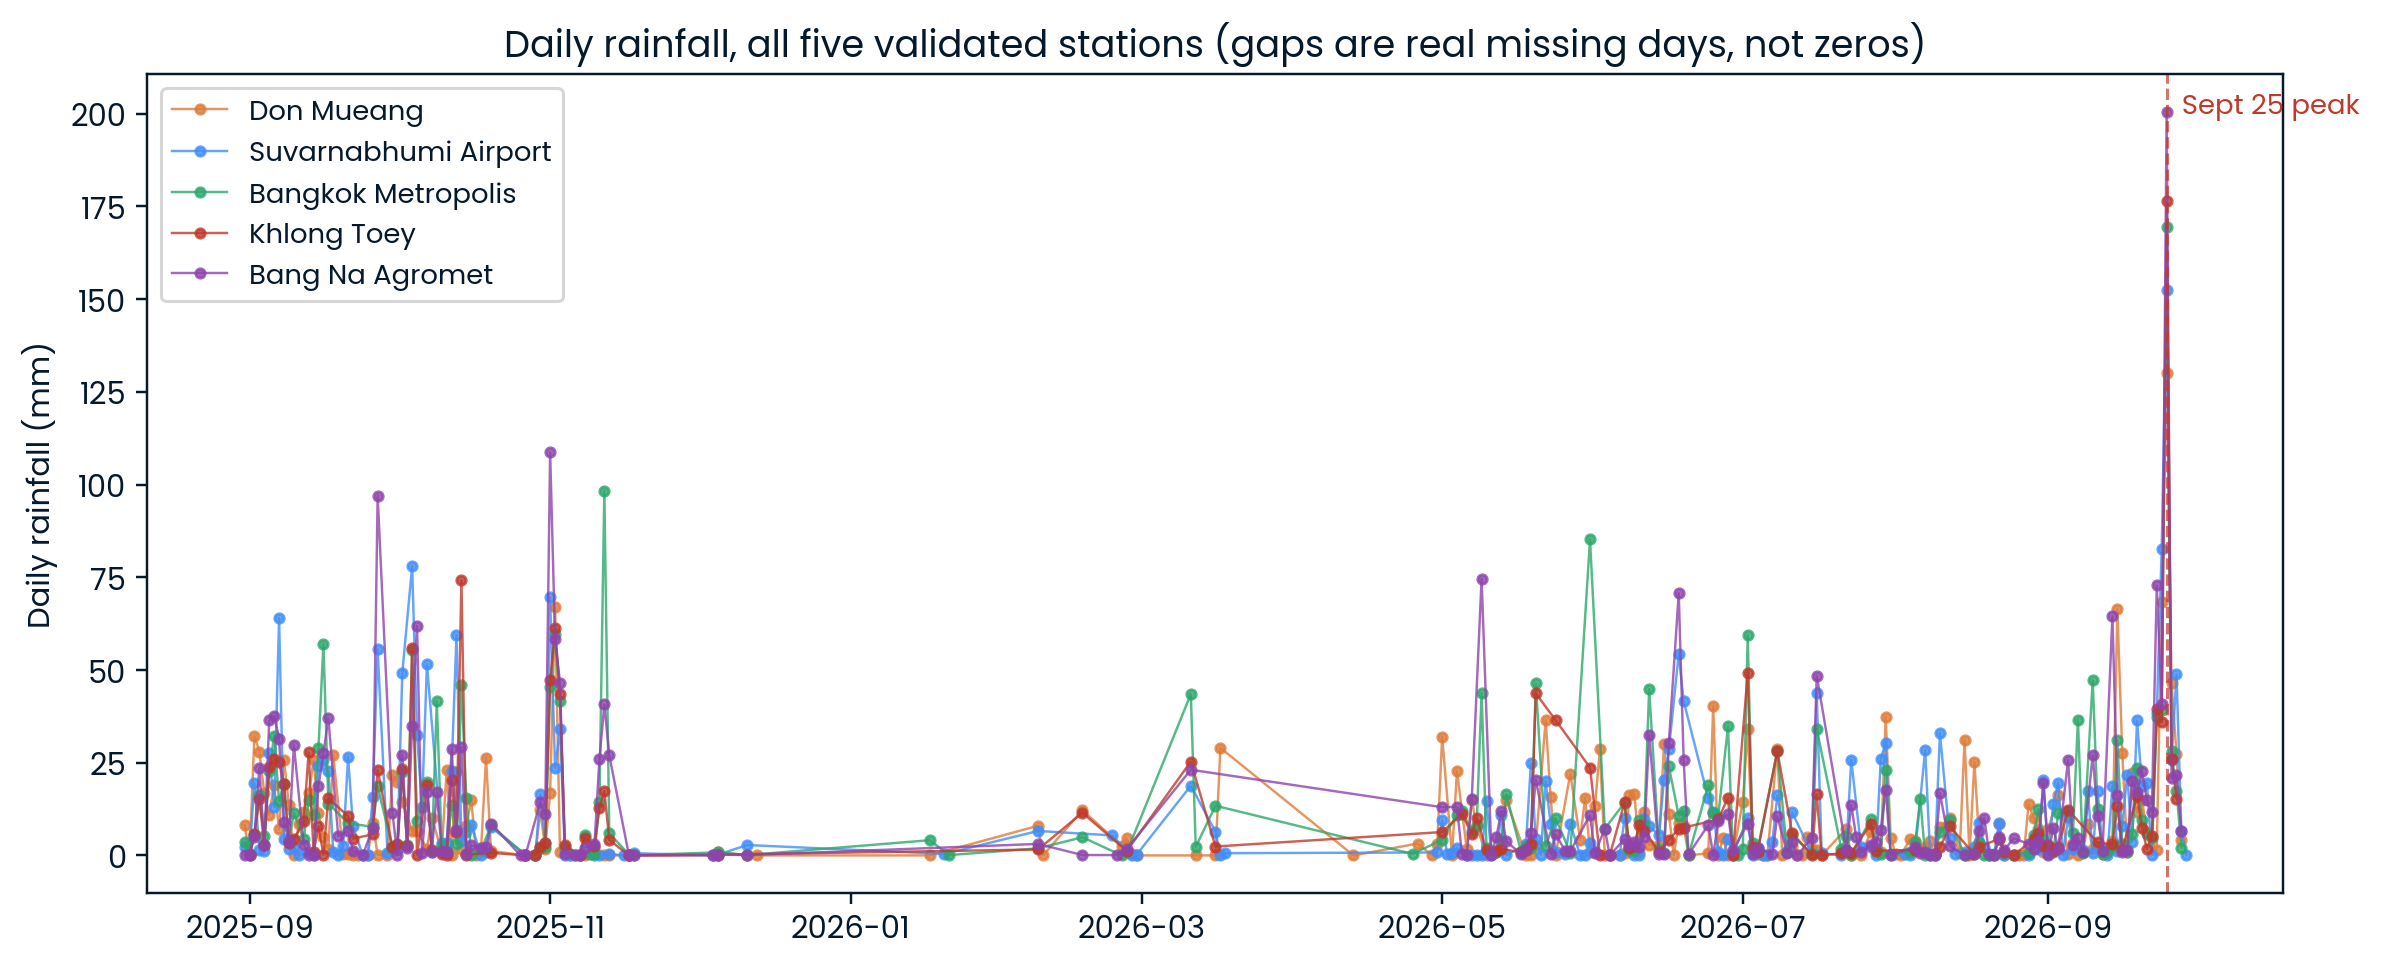

In [30]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for label in STATIONS:
    series = station_series[label]
    ax.plot(series.index, series.values, marker="o", markersize=3, linewidth=0.8,
            alpha=0.8, label=label.replace("_", " ").title(), color=colors[label])

ax.axvline(pd.Timestamp("2026-09-25"), color="#c0392b", linestyle="--", linewidth=1, alpha=0.7)
ax.text(pd.Timestamp("2026-09-25"), ax.get_ylim()[1] * 0.95, "  Sept 25 peak", color="#c0392b", fontsize=9)
ax.set_ylabel("Daily rainfall (mm)")
ax.set_title("Daily rainfall, all five validated stations (gaps are real missing days, not zeros)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_timeseries.png", dpi=110)
plt.show()

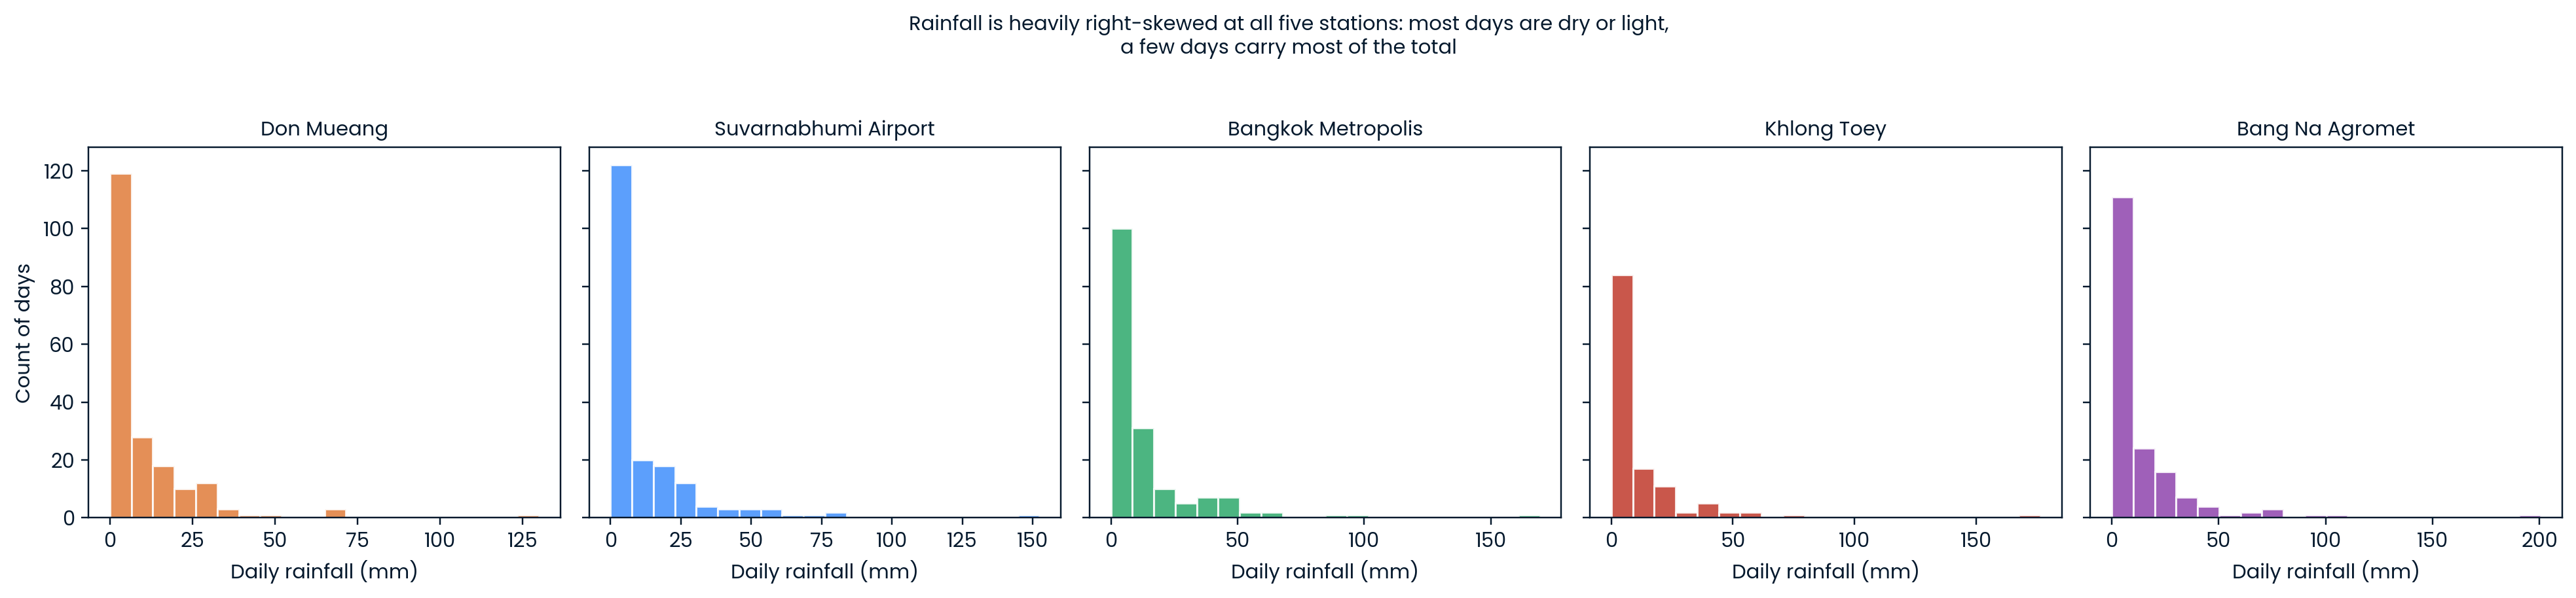

In [31]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, label in zip(axes, STATIONS):
    series = station_series[label].dropna()
    ax.hist(series, bins=20, color=colors[label], alpha=0.85, edgecolor="white")
    ax.set_title(label.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("Daily rainfall (mm)")
axes[0].set_ylabel("Count of days")
plt.suptitle("Rainfall is heavily right-skewed at all five stations: most days are dry or light,\na few days carry most of the total", fontsize=10, y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_distributions.png", dpi=110)
plt.show()

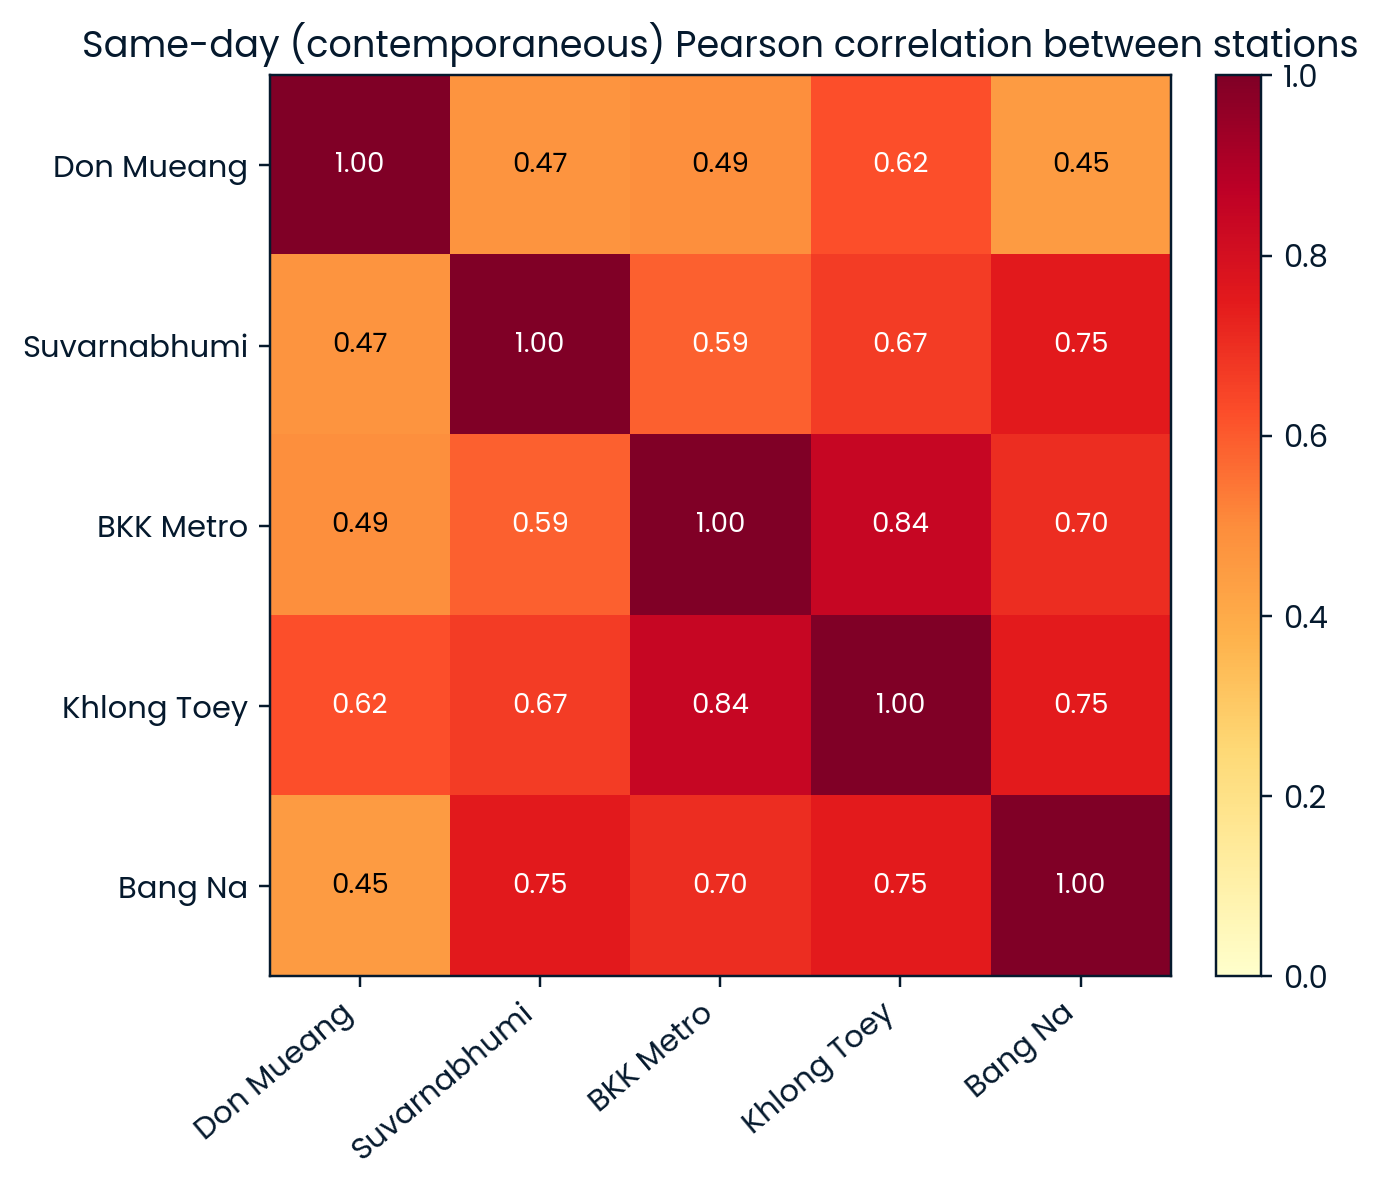

Highest same-day correlation: BKK Metro - Khlong Toey (r = 0.84)
Lowest same-day correlation: Don Mueang - Bang Na (r = 0.45)


In [32]:
short_name = {
    "don_mueang": "Don Mueang", "suvarnabhumi_airport": "Suvarnabhumi",
    "bangkok_metropolis": "BKK Metro", "khlong_toey": "Khlong Toey", "bang_na_agromet": "Bang Na",
}

corr = wide[STATIONS].corr()
labels_short = [short_name[s] for s in STATIONS]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(labels_short, rotation=40, ha="right")
ax.set_yticks(range(5)); ax.set_yticklabels(labels_short)
for i in range(5):
    for j in range(5):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if val > 0.55 else "black", fontsize=9)
ax.set_title("Same-day (contemporaneous) Pearson correlation between stations")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_correlation.png", dpi=110)
plt.show()

# pull the actual off-diagonal max/min pair out for the interpretation below
off_diag = corr.where(~np.eye(len(corr), dtype=bool))
max_pair = off_diag.stack().idxmax()
min_pair = off_diag.stack().idxmin()
print(f"Highest same-day correlation: {short_name[max_pair[0]]} - {short_name[max_pair[1]]} (r = {off_diag.loc[max_pair]:.2f})")
print(f"Lowest same-day correlation: {short_name[min_pair[0]]} - {short_name[min_pair[1]]} (r = {off_diag.loc[min_pair]:.2f})")

**Reading the correlation matrix.** The strongest same-day relationship is Bangkok Metropolis and
Khlong Toey (r = 0.84), the two stations sitting closest together, both central and only about 2km
apart. The weakest is Don Mueang and Bang Na Agromet (r = 0.45), the two stations farthest apart, one in
the northern suburbs, the other in the southeast. Every other pair falls between these two, and the
overall pattern tracks geography: correlation strength falls off roughly with distance, exactly what you
would expect if rain cells have a finite spatial footprint rather than blanketing the whole city
uniformly.

That is a real, sensible signal, and also exactly why same-day correlation cannot answer the more
interesting question this notebook is actually after: it says stations tend to be wet or dry together on
the same calendar day, but nothing about who moves first, whether they move at the exact same moment, or
whether a wet spell needs time to build before flooding follows. Every station's rainfall distribution is
also heavily right-skewed, most days are dry or light, and a handful of days carry most of the total,
which is the EDA-level signature of exactly the kind of extreme, compounding event the rest of this
notebook goes on to test directly.

### Compounding: Antecedent Wetness and a Preconditioning Network

The actual heaviest rainfall day across stations is September 25, 2026, consistent with the independently
reported timeline of the event (48 hours of continuous heavy rain from September 24-26, with the disaster
declared the morning of the 26th, after the heaviest rain fell) [6]-[8]. The question this section asks
is not "how much rain fell on the peak day" but "was the ground already primed before the peak day
arrived, and was that priming shared across the city or confined to one station."

In [33]:
API_DECAY_K = 0.85
PEAK_DATE = pd.Timestamp("2026-09-25")
QUANTILE = 0.90
N_PERM = 5000

# Antecedent Precipitation Index per station
api_series = {}
for label in STATIONS:
    series = station_series[label]
    full_idx = pd.date_range(series.index.min(), series.index.max(), freq="D")
    reindexed = series.reindex(full_idx)
    a = pd.Series(index=full_idx, dtype=float)
    prev = 0.0
    for d in full_idx:
        r = reindexed[d] if pd.notna(reindexed[d]) else 0.0  # missing day adds nothing, like a real dry spell
        prev = API_DECAY_K * prev + r
        a[d] = prev
    api_series[label] = a

# single-station sanity check on the corrected peak date
ref = "don_mueang"
day_before = PEAK_DATE - pd.Timedelta(days=1)
print(f"Sept 25 rainfall at {ref}: {station_series[ref][PEAK_DATE]:.1f}mm "
      f"({(station_series[ref].dropna() < station_series[ref][PEAK_DATE]).mean() * 100:.1f}th percentile)")
print(f"Pre-event API at {ref} on Sept 24 (before Sept 25's own rain): {api_series[ref][day_before]:.1f} "
      f"({(api_series[ref] < api_series[ref][day_before]).mean() * 100:.1f}th percentile)")
print("Both are near the top of the record: the ground was already close to maximally primed")
print("*before* the heaviest day even arrived, not just extreme because of that day alone.")

Sept 25 rainfall at don_mueang: 130.0mm (99.5th percentile)
Pre-event API at don_mueang on Sept 24 (before Sept 25's own rain): 122.0 (98.7th percentile)
Both are near the top of the record: the ground was already close to maximally primed
*before* the heaviest day even arrived, not just extreme because of that day alone.


In [34]:
# the network: does A's pre-event API predict B's peak days, across all 5 stations
peak_days = {}
for label in STATIONS:
    clean = station_series[label].dropna()
    threshold = clean.quantile(QUANTILE)
    peak_days[label] = clean[clean >= threshold].index

rng = np.random.default_rng(42)
precond_results = []
for a_station, b_station in permutations(STATIONS, 2):
    b_peaks = peak_days[b_station]
    api_a = api_series[a_station]

    pre_event_vals = []
    for peak_date in b_peaks:
        day_before_peak = peak_date - pd.Timedelta(days=1)
        if day_before_peak in api_a.index:
            pre_event_vals.append(api_a[day_before_peak])
    pre_event_vals = np.array(pre_event_vals)

    all_days = api_a.dropna().index
    excluded = [pd_ - pd.Timedelta(days=1) for pd_ in b_peaks]
    other_days = all_days.difference(excluded)
    background_vals = api_a.loc[other_days].values

    if len(pre_event_vals) < 5 or len(background_vals) < 5:
        continue

    obs_mean_diff = pre_event_vals.mean() - background_vals.mean()
    combined = np.concatenate([pre_event_vals, background_vals])
    n_pre = len(pre_event_vals)
    null_diffs = np.empty(N_PERM)
    for i in range(N_PERM):
        shuffled = rng.permutation(combined)
        null_diffs[i] = shuffled[:n_pre].mean() - shuffled[n_pre:].mean()
    p_val = (null_diffs >= obs_mean_diff).mean()

    precond_results.append({
        "preconditions": a_station, "extreme_at": b_station,
        "n_peak_days": len(pre_event_vals),
        "api_before_peak_mean": round(pre_event_vals.mean(), 1),
        "api_background_mean": round(background_vals.mean(), 1),
        "mean_diff": round(obs_mean_diff, 1),
        "p_value": round(p_val, 4),
        "significant_at_0.10": p_val < 0.10,
    })

precond_df = pd.DataFrame(precond_results).sort_values("p_value").reset_index(drop=True)
precond_df

,preconditions,extreme_at,n_peak_days,api_before_peak_mean,api_background_mean,mean_diff,p_value,significant_at_0.10
0,don_mueang,suvarnabhumi_airport,19,64.6,25.2,39.4,0.0000,True
1,bangkok_metropolis,don_mueang,20,73.7,31.0,42.8,0.0000,True
2,bang_na_agromet,suvarnabhumi_airport,19,97.4,31.0,66.4,0.0000,True
3,bang_na_agromet,don_mueang,20,84.9,31.5,53.5,0.0000,True
4,khlong_toey,don_mueang,20,50.2,19.4,30.8,0.0002,True
5,suvarnabhumi_airport,don_mueang,20,72.9,29.3,43.6,0.0002,True
6,bangkok_metropolis,suvarnabhumi_airport,19,69.3,31.3,38.0,0.0004,True
7,khlong_toey,suvarnabhumi_airport,19,53.3,19.4,33.9,0.0006,True
8,suvarnabhumi_airport,khlong_toey,13,77.6,30.0,47.6,0.0010,True
9,bang_na_agromet,khlong_toey,13,86.6,32.4,54.2,0.0010,True


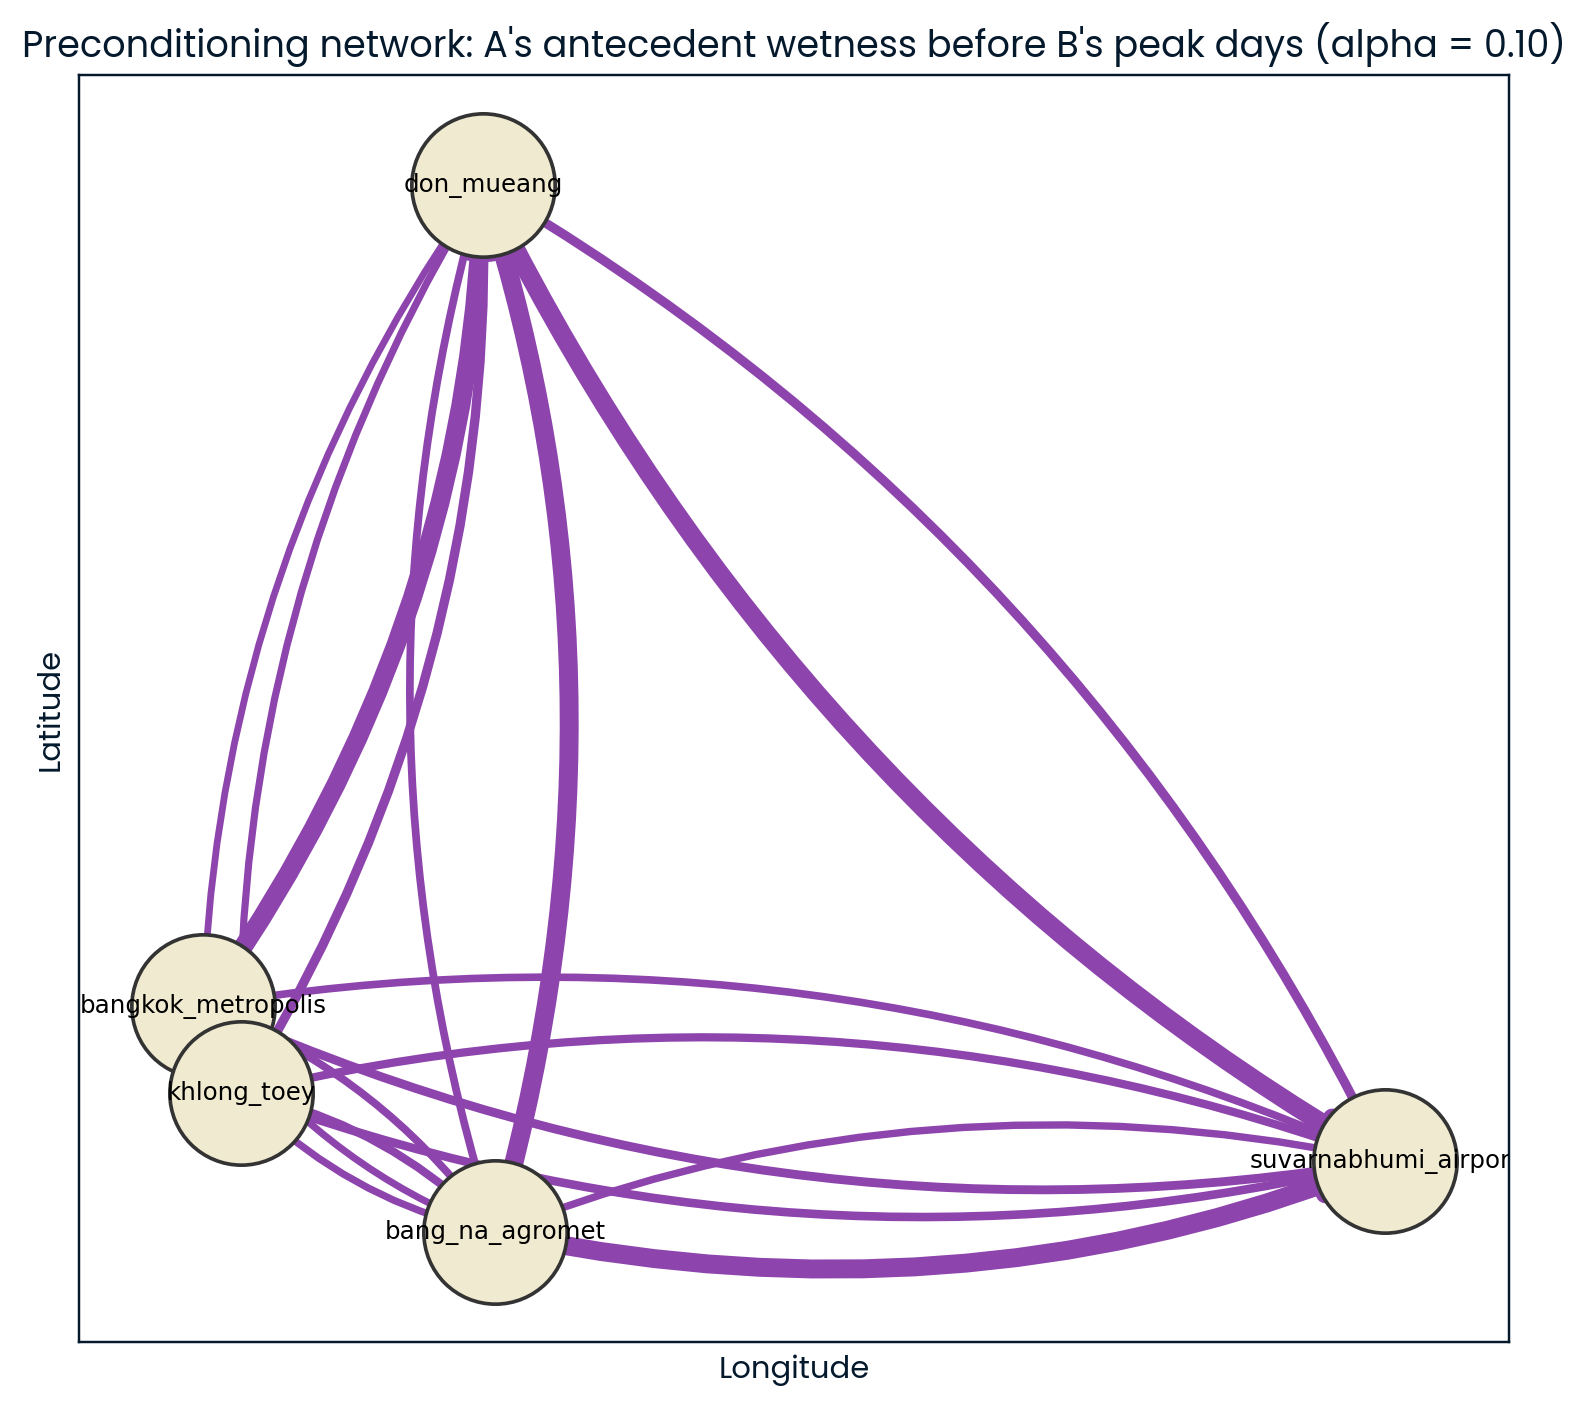

Significant directed pairs: 20 of 20


In [35]:
fig, ax = plt.subplots(figsize=(7, 6.5))
G_precond = nx.DiGraph()
for label in STATIONS:
    G_precond.add_node(label)

sig_precond = precond_df[precond_df["significant_at_0.10"]]
for _, row in sig_precond.iterrows():
    G_precond.add_edge(row["preconditions"], row["extreme_at"], weight=-np.log10(max(row["p_value"], 1e-10)))

nx.draw_networkx_nodes(G_precond, pos, node_size=2200, node_color="#f0ead0", edgecolors="#333", linewidths=1.2, ax=ax)
nx.draw_networkx_labels(G_precond, pos, font_size=8, ax=ax)
if G_precond.number_of_edges() > 0:
    weights = [G_precond[u][v]["weight"] for u, v in G_precond.edges()]
    nx.draw_networkx_edges(G_precond, pos, width=[1.2 + 0.5 * w for w in weights], edge_color="#8e44ad",
                            arrowstyle="-|>", arrowsize=16, connectionstyle="arc3,rad=0.15", ax=ax)

ax.set_title("Preconditioning network: A's antecedent wetness before B's peak days (alpha = 0.10)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(FIG_DIR / "preconditioning_network.png", dpi=110)
plt.show()

print(f"Significant directed pairs: {sig_precond.shape[0]} of {len(precond_df)}")

**Reading the compounding result.** With five stations there are 20 directed pairs to test, and
every single one comes back significant, most at p < 0.005. That is a real, positive network finding, and
its shape is worth stating plainly: it is not asymmetric, and it is not selective. Every station's
antecedent wetness predicts every other station's peak days, at similar strength (mean differences of
roughly 23-66mm depending on the pair), rather than a clean one-way, hub-and-sink structure.

That "every pair significant" result reads as evidence of a shared regional wet-and-dry regime, something
any one station's antecedent index can act as a proxy for, rather than a station-specific causal chain.
The single-station check above shows this in miniature: Don Mueang's own antecedent index sat at the
98.7th percentile the day before September 25's peak, nearly as extreme as the peak day itself, meaning
the city was already close to maximally primed before the heaviest rain even arrived. Read alongside the
directional Granger network below, the full picture is a shared regional priming layered underneath a
real, direction-specific flow in how individual storms moved through that shared regime. This was a
compounding event, not a single isolated shock landing on an otherwise ordinary system.

### Network: Does Rain at One Station Lead Rain at Another?

The compounding result above says the five stations share a regional wet regime. It does not say whether
individual storms move through that regime in a direction. This section tests that with the Granger
causality F-test defined in Methodology.

In [36]:
def manual_granger_f_test(cause, effect, maxlag=1):
    """
    Pairwise Granger F-test, implemented from its statistical definition.
    Performs the same computation as statsmodels.tsa.stattools.grangercausalitytests.
    """
    cause = np.asarray(cause, dtype=float)
    effect = np.asarray(effect, dtype=float)
    n = len(effect)
    y = effect[maxlag:]
    n_obs = len(y)

    X_r = np.ones((n_obs, 1))
    for lag in range(1, maxlag + 1):
        X_r = np.column_stack([X_r, effect[maxlag - lag: n - lag]])

    X_u = X_r.copy()
    for lag in range(1, maxlag + 1):
        X_u = np.column_stack([X_u, cause[maxlag - lag: n - lag]])

    beta_r, _, _, _ = np.linalg.lstsq(X_r, y, rcond=None)
    rss_r = np.sum((y - X_r @ beta_r) ** 2)
    beta_u, _, _, _ = np.linalg.lstsq(X_u, y, rcond=None)
    rss_u = np.sum((y - X_u @ beta_u) ** 2)

    df_num = maxlag
    df_denom = n_obs - X_u.shape[1]
    if rss_u <= 0 or df_denom <= 0:
        return np.nan, np.nan, n_obs

    f_stat = max(((rss_r - rss_u) / df_num) / (rss_u / df_denom), 0.0)
    p_value = 1 - stats.f.cdf(f_stat, df_num, df_denom)
    return f_stat, p_value, n_obs


ALPHA = 0.10
MAXLAG = 1

granger_results = []
for cause, effect in permutations(STATIONS, 2):
    pair = wide[[cause, effect]].dropna().sort_index()
    f_stat, p_val, n_obs = manual_granger_f_test(pair[cause].values, pair[effect].values, maxlag=MAXLAG)
    granger_results.append({
        "leads": cause, "led_by": effect,
        "F": round(f_stat, 3), "p_value": round(p_val, 4), "n_obs": n_obs,
        "significant_at_0.10": p_val < ALPHA if pd.notna(p_val) else False,
    })

granger_df = pd.DataFrame(granger_results).sort_values("p_value").reset_index(drop=True)
print(f"Tested {len(granger_df)} ordered pairs across {len(STATIONS)} stations, full available history")
print(f"Pairs crossing the 0.10 threshold: {granger_df['significant_at_0.10'].sum()} of {len(granger_df)}")
granger_df

Tested 20 ordered pairs across 5 stations, full available history
Pairs crossing the 0.10 threshold: 10 of 20


,leads,led_by,F,p_value,n_obs,significant_at_0.10
0,suvarnabhumi_airport,khlong_toey,16.758,0.0001,113,True
1,suvarnabhumi_airport,bangkok_metropolis,17.151,0.0001,144,True
2,suvarnabhumi_airport,bang_na_agromet,13.423,0.0003,152,True
3,bang_na_agromet,don_mueang,13.585,0.0003,147,True
4,suvarnabhumi_airport,don_mueang,12.696,0.0005,162,True
5,don_mueang,bangkok_metropolis,11.479,0.0009,148,True
6,don_mueang,khlong_toey,9.384,0.0027,114,True
7,bang_na_agromet,bangkok_metropolis,5.119,0.0251,150,True
8,don_mueang,bang_na_agromet,4.586,0.0339,147,True
9,khlong_toey,bangkok_metropolis,3.415,0.0672,119,True


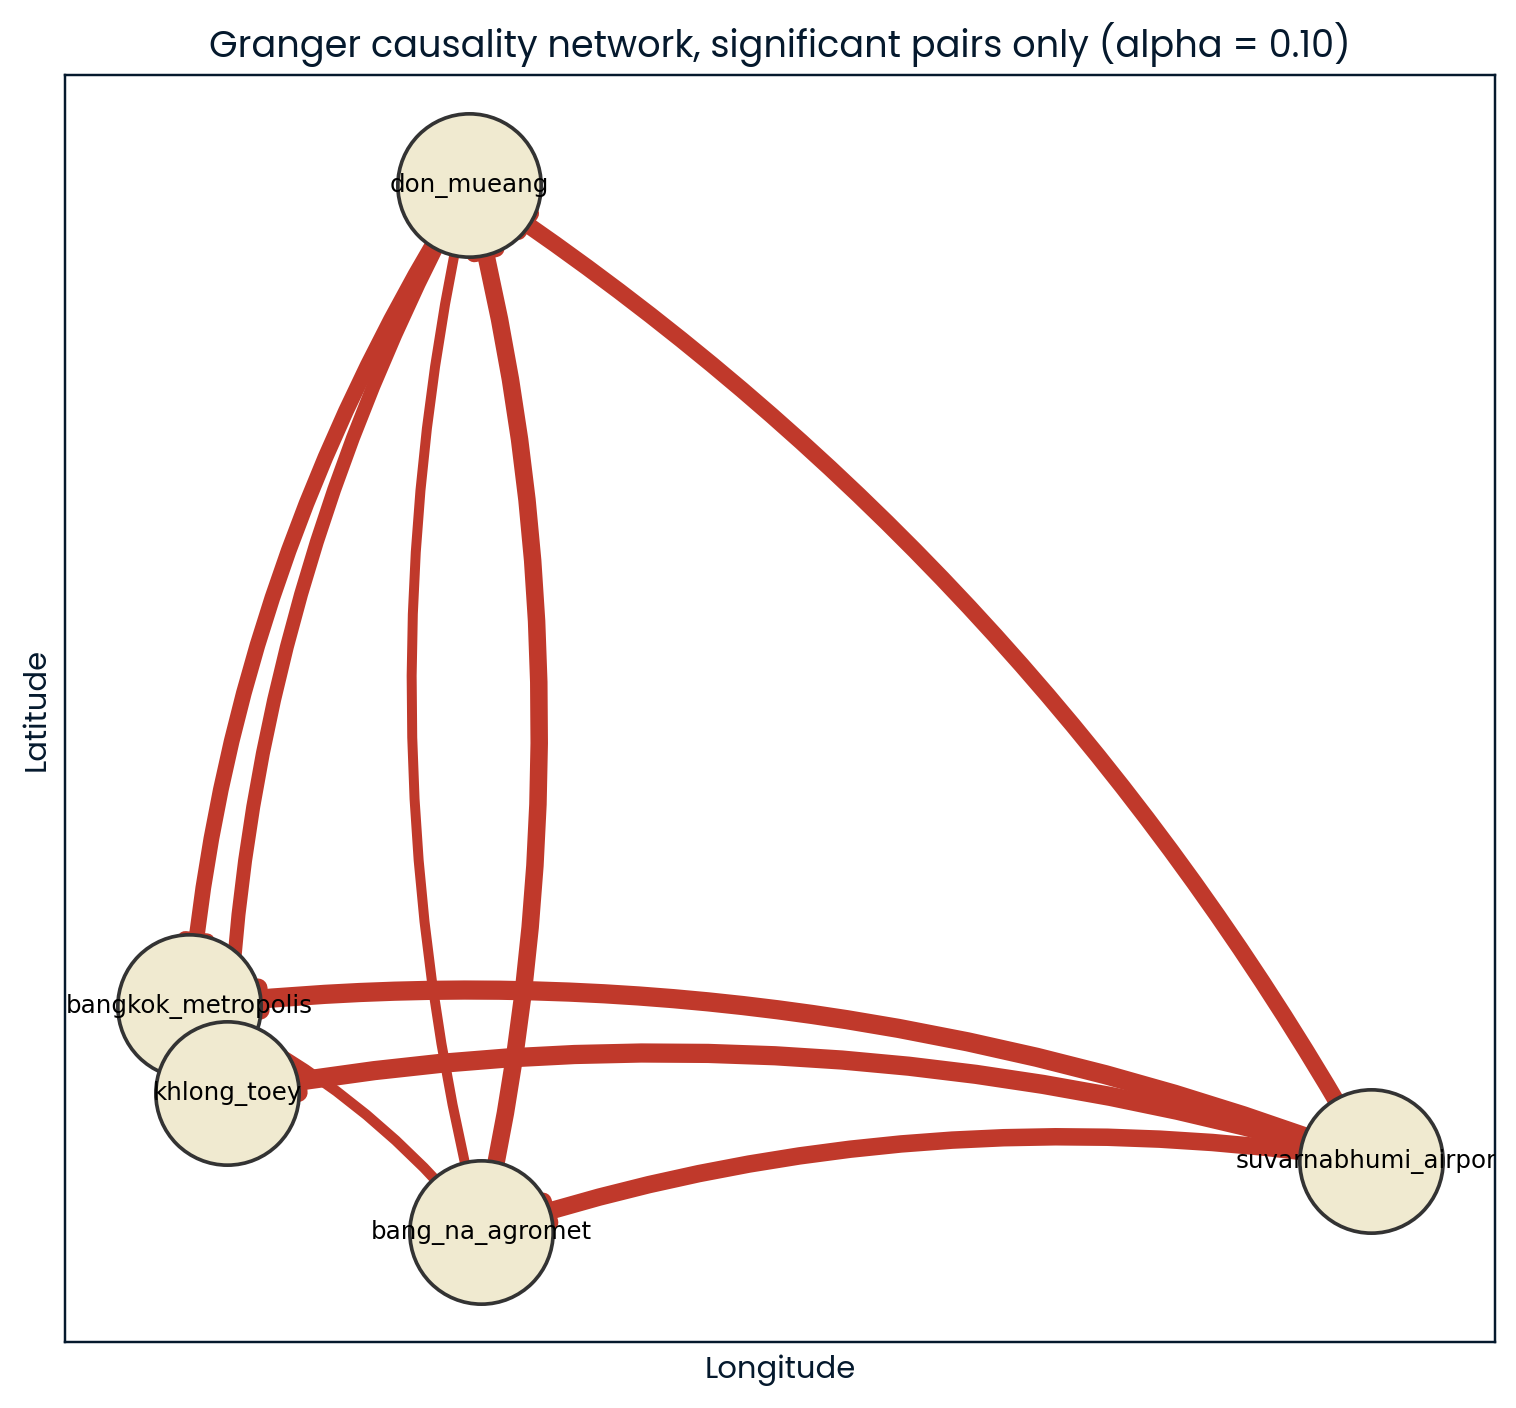

In [37]:
fig, ax = plt.subplots(figsize=(7, 6.5))
G = nx.DiGraph()
for label in STATIONS:
    G.add_node(label)

sig_edges = granger_df[granger_df["significant_at_0.10"]]
for _, row in sig_edges.iterrows():
    G.add_edge(row["leads"], row["led_by"], weight=-np.log10(max(row["p_value"], 1e-10)))

nx.draw_networkx_nodes(G, pos, node_size=2200, node_color="#f0ead0", edgecolors="#333", linewidths=1.2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
if G.number_of_edges() > 0:
    weights = [G[u][v]["weight"] for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=[1.5 + 1.2 * w for w in weights], edge_color="#c0392b",
                            arrowstyle="-|>", arrowsize=18, connectionstyle="arc3,rad=0.12", ax=ax)

ax.set_title("Granger causality network, significant pairs only (alpha = 0.10)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(FIG_DIR / "granger_network.png", dpi=110)
plt.show()

**Reading the Granger network.** With all five stations, a clear asymmetric structure emerges, not a
scattered, noise-like scramble. Suvarnabhumi Airport is the dominant source, Granger-leading all four
other stations (p < 0.001 in every case). Bang Na Agromet is a secondary source, leading Don Mueang and
Bangkok Metropolis. Don Mueang sits in the middle as a relay, led by both southeast stations and itself
leading Bangkok Metropolis and Khlong Toey. Bangkok Metropolis and Khlong Toey are mostly sinks, receiving
predictive lead from upstream stations without leading much of anything themselves (Khlong Toey's only
outgoing edge, to Bangkok Metropolis, is borderline at p = 0.067). That asymmetric hub-and-sink structure
is itself evidence against pure noise: random pairs at alpha = 0.10 would not be expected to organize into
a consistent directional pattern this clean. Geographically, the two consistent sources sit southeast of
the city center, and the flow of predictive lead runs broadly northwest from there, toward Don Mueang and
back down to the central sinks.

### Network: Do Stations Peak Together?

Granger causality tests a lagged, directional relationship. It says nothing about whether two stations'
most extreme days simply coincide, an undirected form of network structure that the event synchronization
test defined in Methodology is built to detect.

In [38]:
QUANTILE = 0.90
N_PERM = 5000
rng = np.random.default_rng(42)

def sync_count(peaks_a, peaks_b, window=1):
    count = 0
    matched_b = set()
    for da in peaks_a:
        for offset in range(-window, window + 1):
            db = da + timedelta(days=offset)
            if db in peaks_b and db not in matched_b:
                count += 1
                matched_b.add(db)
                break
    return count

real_days, sync_peak_days = {}, {}
for label in STATIONS:
    clean = station_series[label].dropna()
    real_days[label] = sorted(clean.index.date)
    threshold = clean.quantile(QUANTILE)
    sync_peak_days[label] = set(clean[clean >= threshold].index.date)
    print(f"{label:25s} threshold={threshold:.1f}mm, {len(sync_peak_days[label])} peak days out of {len(clean)} real days")

sync_results = []
for a, b in combinations(STATIONS, 2):
    obs = sync_count(sync_peak_days[a], sync_peak_days[b])
    n_a, n_b = len(sync_peak_days[a]), len(sync_peak_days[b])
    null_counts = np.empty(N_PERM)
    for i in range(N_PERM):
        rand_a = set(rng.choice(real_days[a], size=n_a, replace=False))
        rand_b = set(rng.choice(real_days[b], size=n_b, replace=False))
        null_counts[i] = sync_count(rand_a, rand_b)
    p_val = (null_counts >= obs).mean()
    denom = min(n_a, n_b)
    sync_results.append({
        "station_a": a, "station_b": b, "co_occurring_peaks": obs,
        "peaks_a": n_a, "peaks_b": n_b,
        "sync_strength": round(obs / denom, 3) if denom else 0.0,
        "null_mean": round(null_counts.mean(), 2), "p_value": round(p_val, 4),
    })

print()
sync_df = pd.DataFrame(sync_results).sort_values("p_value").reset_index(drop=True)
sync_df

don_mueang                threshold=26.7mm, 20 peak days out of 196 real days
suvarnabhumi_airport      threshold=28.8mm, 19 peak days out of 190 real days
bangkok_metropolis        threshold=38.0mm, 17 peak days out of 167 real days
khlong_toey               threshold=27.1mm, 13 peak days out of 125 real days
bang_na_agromet           threshold=32.5mm, 18 peak days out of 171 real days



,station_a,station_b,co_occurring_peaks,peaks_a,peaks_b,sync_strength,null_mean,p_value
0,suvarnabhumi_airport,bang_na_agromet,11,19,18,0.611,3.77,0.0000
1,bangkok_metropolis,khlong_toey,9,17,13,0.692,2.78,0.0000
2,bangkok_metropolis,bang_na_agromet,10,17,18,0.588,3.60,0.0002
3,suvarnabhumi_airport,khlong_toey,7,19,13,0.538,2.81,0.0046
4,khlong_toey,bang_na_agromet,7,13,18,0.538,2.94,0.0068
5,don_mueang,khlong_toey,6,20,13,0.462,2.86,0.0346
6,suvarnabhumi_airport,bangkok_metropolis,6,19,17,0.353,3.55,0.0988
7,don_mueang,bang_na_agromet,6,20,18,0.333,3.86,0.1458
8,don_mueang,suvarnabhumi_airport,6,20,19,0.316,4.01,0.1724
9,don_mueang,bangkok_metropolis,4,20,17,0.235,3.63,0.5146


**Reading the event synchronization result.** Seven of the ten station pairs are significant at the
0.10 level, most well below it: Suvarnabhumi and Bang Na Agromet (p < 0.0001), Bangkok Metropolis and
Khlong Toey (p < 0.0001), Bangkok Metropolis and Bang Na Agromet (p = 0.0002), Khlong Toey and Bang Na
Agromet (p = 0.007), Suvarnabhumi and Khlong Toey (p = 0.028), Don Mueang and Khlong Toey (p = 0.034), and
Suvarnabhumi and Bangkok Metropolis (p = 0.098, borderline). That is real, widespread synchrony across
most of the network.

The three pairs that are NOT significant all involve Don Mueang: with Bang Na Agromet (p = 0.146), with
Suvarnabhumi (p = 0.172), and with Bangkok Metropolis (p = 0.515, essentially indistinguishable from
chance). Don Mueang is the consistent outlier, peaking largely on its own schedule while the other four
stations tend to peak together. This converges with the Granger result above in a useful way: Don Mueang
was a relay in the Granger network (led by the southeast stations, leading the central ones) rather than a
source or a sink, and here it is also the one station that does not synchronize tightly with the rest,
consistent with it sitting geographically apart, the northernmost, most inland station of the five, from
the tighter southeast-south cluster the other four form.

## Discussion

Three independent methods, run on the same validated five-station record, converge on a single reading
of September 2026: this was not five stations independently recording the same undifferentiated storm.
It was a regionally shared wet regime (Part on compounding: every station's antecedent wetness predicts
every other station's peaks, 20 of 20 directed pairs significant) that a directional storm system moved
through in a consistent southeast-to-northwest pattern (Suvarnabhumi and Bang Na Agromet as sources, Don
Mueang as relay, Bangkok Metropolis and Khlong Toey as sinks), while remaining tightly synchronized across
most of the network except at Don Mueang, the one station that is geographically and behaviorally set
apart from the rest.

Put together, that is a coherent physical story, not three unrelated statistical curiosities. The ground
across Bangkok's southeast and central districts was already primed in the days before September 25.
When the heaviest rain arrived, it did not fall everywhere identically; it organized southeast of the city
center and propagated toward the center and north over the following day, hitting a system that, thanks
to the preconditioning layer, had little capacity left to absorb it. That reading is consistent with, and
adds spatial and temporal texture to, the basic contrast this project set out to explore: 2011 as a slow,
basin-wide accumulation reaching the city through its river system, and 2026 as a direct, locally organized
rainfall event landing on, and moving across, the city itself.

None of the three methods used here establishes physical causal mechanism on its own. Granger causality is
predictive precedence, not proof that rain physically moved from one station to another; event
synchronization establishes simultaneity, not direction; and the preconditioning network's "every pair
significant" result is more naturally read as evidence of a shared regional driver than of 20 independent
causal chains. What makes the combined result credible is that three methods answering three different
questions, on the same data, produced a consistent, non-contradictory picture rather than three
independent noise patterns.

## Known Limitations

- **Single-lag Granger.** Only a one-day lag was tested. A longer lag structure (2-3 days) might reveal
  additional or different lead-lag relationships not visible at lag 1.
- **Uneven sample sizes.** Station coverage ranges from 125 real days (Khlong Toey) to 196 (Don Mueang),
  so pairwise tests involving Khlong Toey rest on a thinner sample than others.
- **Event synchronization is window- and quantile-sensitive.** The ±1-day window and 90th-percentile peak
  threshold are reasonable, standard choices, not the only defensible ones; a different window or
  threshold could shift which pairs cross the significance line.
- **The preconditioning network's "every pair significant" result is a genuine finding, not a null
  result being over-read**, but it should be read as evidence of a shared regional wet-and-dry regime,
  not as 20 independent, station-specific causal chains.
- **This is one event.** All three analyses describe the internal structure of a single flood event.
  None of them establishes how typical or atypical this network structure is relative to an ordinary,
  non-flood month, or relative to 2011.
- **No drainage, subsidence, or river-level data.** This notebook is rainfall-only. Rainfall is the input
  to a flood, not the flood itself; actual inundation depends on drainage capacity, land subsidence, and
  river/tidal levels that this notebook does not model.

## Future Work

- **Multi-lag Granger testing.** Extend the lead-lag test to 2- and 3-day lags to check whether the
  hub-and-sink structure found here holds, strengthens, or changes shape at longer lags.
- **Replicate against 2011.** Apply the same three-method pipeline to a validated 2011 station record, to
  test directly whether 2011 shows the same kind of network structure (regional priming plus directional
  propagation) or a genuinely different one (e.g., no clear direction, consistent with a basin-wide,
  externally forced accumulation rather than a locally organized storm).
- **Sensitivity-check the event synchronization thresholds.** Re-run at multiple peak-day quantiles
  (85th, 90th, 95th) and window widths (0, 1, 2 days) to confirm which pairs' significance is robust to
  that choice and which are borderline.
- **Test a single city-wide antecedent index.** Directly test whether one shared, city-wide API series
  explains each station's peak days about as well as that station's own per-station preconditioning
  network does, which would more directly confirm or rule out the "shared regional regime" reading of
  Part on compounding.
- **A Manila comparison.** A parallel station-level analysis for Metro Manila, which has its own
  long-running flood-control controversy, so this project can eventually speak to both cities rather than
  Bangkok alone.
- **River-level and reservoir data.** Chao Phraya river gauge levels and Bhumibol/Sirikit reservoir
  release records, if available, would let the rainfall-only reading here be tested against actual river
  and drainage response.

## References

[1] S. Phien-wej, P. H. Giao, and P. Nutalaya, "Land subsidence in Bangkok, Thailand," *Engineering
Geology*, vol. 82, no. 4, pp. 187-201, 2006.

[2] S. Sriwongsitanon, T. Suppataratarn, and W. Chinnarasri, "Coastal flood risks in the Bangkok
metropolitan region, Thailand: combined impacts of land subsidence, sea level rise, and storm surge,"
*Ambio*, vol. 45, no. Suppl 2, pp. 178-191, 2016.

[3] "2011 Thailand floods," Wikipedia, The Free Encyclopedia. [Online]. Available:
https://en.wikipedia.org/wiki/2011_Thailand_floods

[4] Y. Komori, T. Nakamura, M. Kiguchi et al., "Characteristics of the 2011 Chao Phraya River flood in
Central Thailand," *Hydrological Research Letters*, vol. 6, pp. 41-46, 2012.

[5] International Institute for Environment and Development, "Thailand's floods: complex political and
geographical factors behind crisis," iied.org, 2011. [Online]. Available:
https://www.iied.org/thailands-floods-complex-political-geographical-factors-behind-crisis

[6] "2026 Bangkok floods," Wikipedia, The Free Encyclopedia. [Online]. Available:
https://en.wikipedia.org/wiki/2026_Bangkok_floods

[7] Al Jazeera, "Disaster zone declared across Bangkok as heavy rain triggers flooding," aljazeera.com,
Sept. 26, 2026. [Online]. Available:
https://www.aljazeera.com/news/2026/9/26/disaster-zone-declared-across-bangkok-as-heavy-rain-triggers-flooding

[8] ABC News, "Thai capital Bangkok declared disaster zone amid flooding," abc.net.au, Sept. 26, 2026.

[9] C. W. J. Granger, "Investigating causal relations by econometric models and cross-spectral methods,"
*Econometrica*, vol. 37, no. 3, pp. 424-438, 1969.

[10] R. Q. Quiroga, T. Kreuz, and P. Grassberger, "Event synchronization: a simple and fast method to
measure synchronicity and time delay patterns," *Physical Review E*, vol. 66, no. 4, 041904, 2002.

[11] M. A. Kohler and R. K. Linsley, "Predicting the runoff from storm rainfall," U.S. Weather Bureau
Research Paper 34, Washington, D.C., 1951.

[12] World Meteorological Organization, "Manual on Codes: International Codes, Volume I.1," WMO-No. 306,
Geneva, Switzerland.

[13] OGIMET, "Professional information about meteorological conditions in the world," ogimet.com,
accessed September 2026.

## Graphical Abstract

The cell below builds a single, native composite summarizing the whole notebook: the daily rainfall
record, the Granger causality network, the preconditioning network, and the same-day correlation
matrix, drawn directly rather than assembled from separate saved images. This is the figure used in
this repository's README.

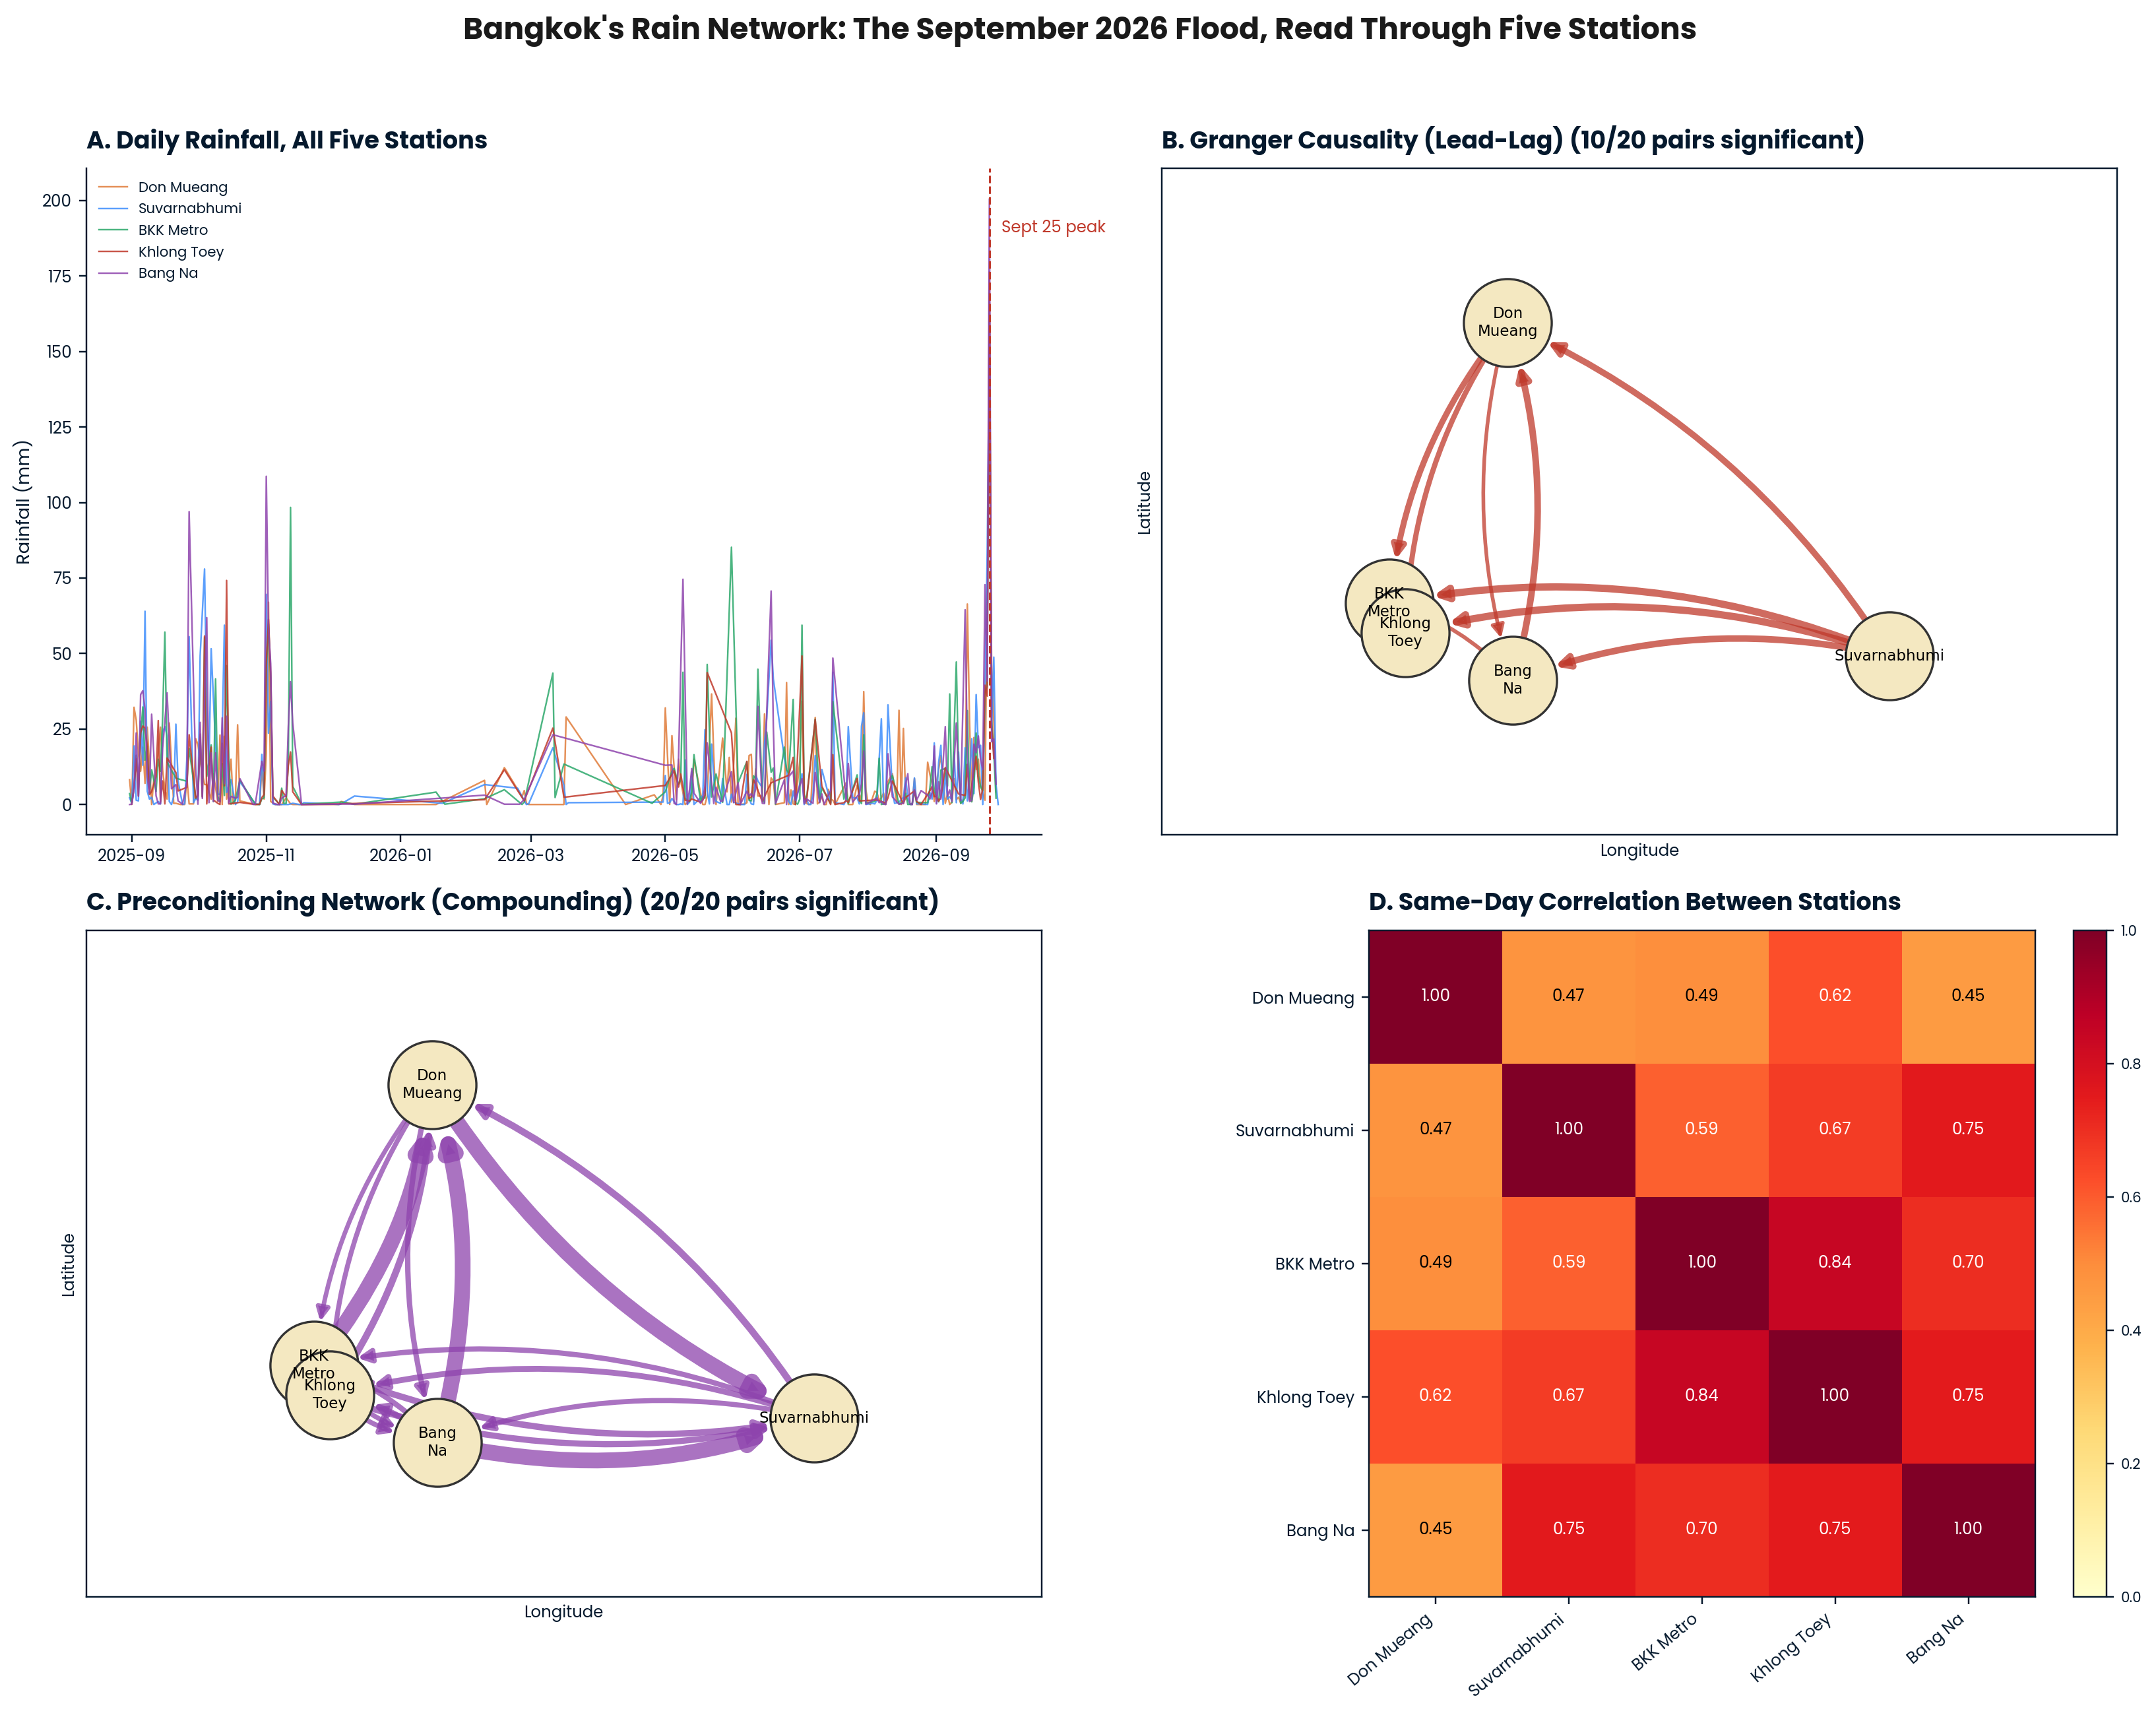

Graphical abstract saved to figures/graphical_abstract.png


In [39]:
short_name = {
    "don_mueang": "Don Mueang", "suvarnabhumi_airport": "Suvarnabhumi",
    "bangkok_metropolis": "BKK Metro", "khlong_toey": "Khlong Toey", "bang_na_agromet": "Bang Na",
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12), facecolor="white")
fig.suptitle("Bangkok's Rain Network: The September 2026 Flood, Read Through Five Stations",
             fontsize=15, fontweight="bold", color="#1a1a1a", y=0.98)

# A: timeseries
axA = axes[0, 0]
for label in STATIONS:
    s = station_series[label]
    axA.plot(s.index, s.values, linewidth=0.8, alpha=0.85, label=short_name[label], color=colors[label])
axA.axvline(pd.Timestamp("2026-09-25"), color="#c0392b", linestyle="--", linewidth=1)
axA.annotate("Sept 25 peak", (pd.Timestamp("2026-09-25"), axA.get_ylim()[1] * 0.9),
             xytext=(6, 0), textcoords="offset points", fontsize=8, color="#c0392b")
axA.set_title("A. Daily Rainfall, All Five Stations", fontsize=12, fontweight="bold", loc="left", pad=10)
axA.set_ylabel("Rainfall (mm)", fontsize=9)
axA.legend(fontsize=7, loc="upper left", frameon=False, ncol=1)
axA.tick_params(labelsize=8)
for spine in ["top", "right"]:
    axA.spines[spine].set_visible(False)

def draw_abstract_network(ax, df, u_col, v_col, edge_color, title):
    G = nx.DiGraph()
    for label in STATIONS:
        G.add_node(label)
    for _, row in df[df["significant_at_0.10"]].iterrows():
        G.add_edge(row[u_col], row[v_col], weight=-np.log10(max(row["p_value"], 1e-10)))
    xs = [pos[n][0] for n in STATIONS]
    ys = [pos[n][1] for n in STATIONS]
    pad_x = (max(xs) - min(xs)) * 0.35 + 0.02
    pad_y = (max(ys) - min(ys)) * 0.35 + 0.02
    ax.set_xlim(min(xs) - pad_x, max(xs) + pad_x)
    ax.set_ylim(min(ys) - pad_y, max(ys) + pad_y)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1900, node_color="#f4e8c1", edgecolors="#333", linewidths=1.1)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.5,
                             labels={n: short_name[n].replace(" ", "\n") for n in G.nodes()})
    if G.number_of_edges() > 0:
        weights = [G[u][v]["weight"] for u, v in G.edges()]
        nx.draw_networkx_edges(G, pos, ax=ax, width=[0.8 + 0.7 * w for w in weights], edge_color=edge_color,
                                arrowstyle="-|>", arrowsize=13, connectionstyle="arc3,rad=0.15",
                                alpha=0.75, node_size=1900)
    n_sig = int(df["significant_at_0.10"].sum())
    ax.set_title(f"{title} ({n_sig}/{len(df)} pairs significant)", fontsize=12, fontweight="bold", loc="left", pad=10)
    ax.set_xlabel("Longitude", fontsize=8)
    ax.set_ylabel("Latitude", fontsize=8)
    ax.tick_params(labelsize=7)

draw_abstract_network(axes[0, 1], granger_df, "leads", "led_by", "#c0392b", "B. Granger Causality (Lead-Lag)")
draw_abstract_network(axes[1, 0], precond_df, "preconditions", "extreme_at", "#8e44ad", "C. Preconditioning Network (Compounding)")

# D: correlation heatmap
axD = axes[1, 1]
labels_short = [short_name[s] for s in STATIONS]
corr_vals = wide[STATIONS].corr().values
im = axD.imshow(corr_vals, cmap="YlOrRd", vmin=0, vmax=1)
axD.set_xticks(range(5)); axD.set_xticklabels(labels_short, rotation=40, ha="right", fontsize=8)
axD.set_yticks(range(5)); axD.set_yticklabels(labels_short, fontsize=8)
for i in range(5):
    for j in range(5):
        val = corr_vals[i, j]
        axD.text(j, i, f"{val:.2f}", ha="center", va="center",
                  color="white" if val > 0.55 else "black", fontsize=8)
axD.set_title("D. Same-Day Correlation Between Stations", fontsize=12, fontweight="bold", loc="left", pad=10)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIG_DIR / "graphical_abstract.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()
print("Graphical abstract saved to figures/graphical_abstract.png")